Load Data
-------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# load dataset dataset_1980_2020.csv
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)
print(raw_data.head())

   Year State  0 to 11  12 to 17  Male  Female  Unknown Gender  White  Black  \
0  1980    AL        0        18    13       5               0      7     10   
1  1981    AL        0        21    19       1               0     13      8   
2  1982    AL        1        19    15       4               0      5     14   
3  1983    AL        2        20    21       1               0      7     15   
4  1984    AL        0        21    19       2               0      7     13   

   Amer. Indian/Alaskan Native  ...  Stranger  Unknown  Firearm  Knife  \
0                            1  ...         4        0       15      3   
1                            0  ...         5        0       13      8   
2                            0  ...         6        0        7      5   
3                            0  ...         4        0       13      7   
4                            0  ...         5        2       12      3   

   Blunt object  Personal  Other/unknown Weapon  One offender involved  \


Pre processing
-------------------

In [ ]:
# give each state a numerical value
encoder = LabelEncoder()
raw_data["State"] = encoder.fit_transform(raw_data["State"])

# Define the features (excluding 'Year' and 'Count')
features = raw_data.columns.difference(["Year", "Count"])

# Define target variables (Male and Female)
targets = ["Male", "Female"]

# Define X and y
X = raw_data[features]
y = raw_data[targets]  # Multiple target columns (Male and Female)

# Split the data into training and testing sets (80% training, 20% testing)
train_size = int(len(raw_data) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Training and Evaluation
-------------

Male Model Performance:
MAE: 0.02
MSE: 0.01
R² Score: 1.00


Female Model Performance:
MAE: 0.00
MSE: 0.00
R² Score: 1.00




c:\Users\nsano\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\nsano\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


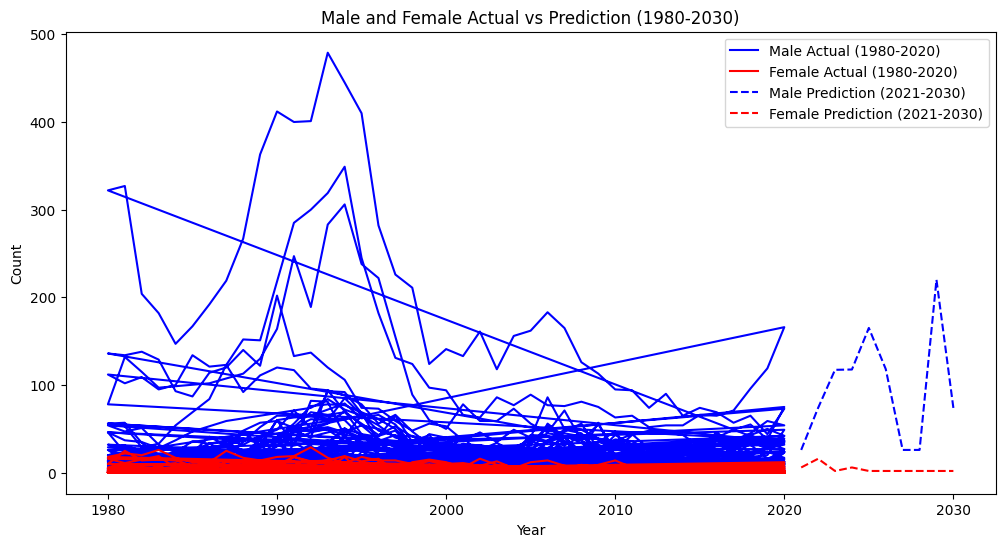

In [ ]:
# Train models for Male and Female
models = {}
for target in targets:
    model = RandomForestRegressor()  # You can choose a different model
    model.fit(X_train, y_train[target])  # Train model for each target
    models[target] = model

# Evaluate models for Male and Female
for target, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test[target], y_pred)
    mse = mean_squared_error(y_test[target], y_pred)
    r2 = r2_score(y_test[target], y_pred)
    
    print(f"{target} Model Performance:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print("\n")
    
# Create a DataFrame for future years (2021 to 2030)
future_years = pd.DataFrame({'Year': np.arange(2021, 2031)})

# Use the data from 2020 as a template for future years
last_data = raw_data[raw_data['Year'] == 2020].drop(columns=["Year"])

# For simplicity, we'll repeat 2020 data for the years 2021-2030
future_years = pd.concat([future_years, pd.DataFrame(np.tile(last_data.values, (len(future_years), 1)), columns=last_data.columns)], axis=1)

# Drop 'Year' column for prediction
future_years = future_years.drop(columns=["Year"])

# Loop over the models and predict for the future years (2021-2030)
future_predictions = {}
for target, model in models.items():
    future_predictions[target] = model.predict(future_years)

# Plot predictions for 1980-2020 (Actual Data)
plt.figure(figsize=(12, 6))

# Plot actual data for Male and Female for 1980-2020 (solid lines)
plt.plot(raw_data['Year'], raw_data['Male'], label="Male Actual (1980-2020)", color='blue')
plt.plot(raw_data['Year'], raw_data['Female'], label="Female Actual (1980-2020)", color='red')

# Plot predictions for Male and Female for 2021-2030 (dashed lines)
plt.plot(np.arange(2021, 2031), future_predictions["Male"][:10], label="Male Prediction (2021-2030)", linestyle='dashed', color='blue')
plt.plot(np.arange(2021, 2031), future_predictions["Female"][:10], label="Female Prediction (2021-2030)", linestyle='dashed', color='red')

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Male and Female Actual vs Prediction (1980-2030)")
plt.legend()

# Show the plot
plt.show()

